In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Load & Prepare
df = pd.read_csv('BankChurners.csv')
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# Drop leakage/ID columns
drop_cols = ['CLIENTNUM', 'Credit_Limit', 'Dependent_count', 'Avg_Open_To_Buy',
             'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
             'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

# 2. STRATIFIED SPLIT (Done BEFORE any preprocessing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

# 3. Safe Feature Engineering
def engineer_features(X_df):
    df_eng = X_df.copy()
    df_eng['avg_amt_per_txn'] = df_eng['Total_Trans_Amt'] / (df_eng['Total_Trans_Ct'] + 1e-9)
    df_eng['engagement_score'] = df_eng['Total_Trans_Ct'] * df_eng['Avg_Utilization_Ratio']
    return df_eng

# 4. Preprocessor Pipeline (Fits ONLY on training folds during CV/Training)
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]),
     ['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
      'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
      'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'),
     ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category'])
])

print("✅ Data split & preprocessor ready. Train:", X_train.shape, "Test:", X_test.shape)

✅ Data split & preprocessor ready. Train: (7088, 16) Test: (3039, 16)


In [2]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
def make_pipeline(model):
    return Pipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', clone(preprocessor)),
        ('mdl', model)
    ])


In [3]:
def make_stacking_base(model):

    return Pipeline([
        ('feature_engineering', FunctionTransformer(engineer_features)),
        ('preprocessor', clone(preprocessor)),
        ('mdl', clone(model))
    ])


In [4]:


#  base classifiers (used for both standalone & stacking)
base_rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=5, class_weight='balanced', random_state=42)
base_gb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=3, class_weight='balanced', random_state=42) # ✅ Fixes GB imbalance
base_xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, 
                         scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss', random_state=42, use_label_encoder=False)
base_cat = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=4, random_state=42, verbose=0)
# seperate stacking base estimators for LR and XGB meta-learners to avoid data leakage from fitted models
stack_rf_lr = RandomForestClassifier(n_estimators=300, max_depth=8,
min_samples_split=5, class_weight='balanced', random_state=42)
stack_gb_lr = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
max_depth=3, class_weight='balanced', random_state=42)
stack_xgb_lr = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
subsample=0.8, colsample_bytree=0.8,

scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss',
random_state=42)

stack_rf_xgb = RandomForestClassifier(n_estimators=300, max_depth=8,
min_samples_split=5, class_weight='balanced', random_state=42)
stack_gb_xgb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
max_depth=3, class_weight='balanced', random_state=42)
stack_xgb_xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
subsample=0.8, colsample_bytree=0.8,

scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss',
random_state=42)
# Stacking estimators for LR meta-learner
stack_est_lr = [
    ('rf', make_stacking_base(stack_rf_lr)),
    ('gb', make_stacking_base(stack_gb_lr)),
    ('xgb', make_stacking_base(stack_xgb_lr))
]
# Stacking estimators for XGB meta-learner (fresh independent copies)
stack_est_xgb_named = [
    ('rf', make_stacking_base(stack_rf_xgb)),
    ('gb', make_stacking_base(stack_gb_xgb)),
    ('xgb', make_stacking_base(stack_xgb_xgb))
]

models = {                                                                                                 
    'Random Forest': make_pipeline(base_rf),
    'Gradient Boosting': make_pipeline(base_gb),                                                           
    'XGBoost': make_pipeline(base_xgb),                                                                    
    'CatBoost': make_pipeline(base_cat),                                                                   
    'Stacking (LR Meta)': Pipeline([                                                                       
        ('stack', StackingClassifier(estimators=stack_est_lr,                                              
                                    final_estimator=LogisticRegression(max_iter=1000,                     
class_weight='balanced'),                                                                                  
                                    cv=5, stack_method='predict_proba', passthrough=False, n_jobs=-1))    
    ]),                                                                                                    
    'Stacking (XGB Meta)': Pipeline([                                                                      
        ('stack', StackingClassifier(estimators=stack_est_xgb_named,                                       
                                    final_estimator=XGBClassifier(n_estimators=200, learning_rate=0.05,   
max_depth=4,                                                                                               
                                    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),            
                                    eval_metric='logloss', random_state=42),                              
                                    cv=5, stack_method='predict_proba', passthrough=False, n_jobs=-1))    
    ])                                                                                                     
} 
print("✅ 6 models configured with identical pipelines & class-imbalance handling.")

✅ 6 models configured with identical pipelines & class-imbalance handling.


/Users/sayanbhattacharyya/Desktop/Final Project 3rd/venv_new_2/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [5]:
THRESHOLD = 0.50
results = []

print(f"🔍 Running fair comparison (Threshold locked at {THRESHOLD})...\n")
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (Churn)': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'Recall (Churn)': round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'F1-Score (Churn)': round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })
    print(f"✅ {name} evaluated.")

# Display Comparison Table
df_comp = pd.DataFrame(results)
print("\n" + "="*85)
print("📊 FAIR MODEL COMPARISON (Threshold = 0.50 | Churn = Positive Class)")
print("="*85)
print(df_comp.to_string(index=False))
print("="*85)

🔍 Running fair comparison (Threshold locked at 0.5)...

✅ Random Forest evaluated.
✅ Gradient Boosting evaluated.
✅ XGBoost evaluated.
✅ CatBoost evaluated.
✅ Stacking (LR Meta) evaluated.
✅ Stacking (XGB Meta) evaluated.

📊 FAIR MODEL COMPARISON (Threshold = 0.50 | Churn = Positive Class)
              Model  Accuracy  Precision (Churn)  Recall (Churn)  F1-Score (Churn)  ROC-AUC
      Random Forest    0.9457             0.7942          0.8934            0.8409   0.9817
  Gradient Boosting    0.9500             0.7887          0.9406            0.8579   0.9910
            XGBoost    0.9645             0.8571          0.9344            0.8941   0.9934
           CatBoost    0.9658             0.9324          0.8484            0.8884   0.9915
 Stacking (LR Meta)    0.9589             0.8247          0.9447            0.8806   0.9930
Stacking (XGB Meta)    0.9585             0.8255          0.9406            0.8793   0.9926


In [56]:
#classification report for the best model (LR meta-learner)
from sklearn.metrics import classification_report
best_model = models['Stacking (LR Meta)'] # ✅ Fixes typo in model name
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= THRESHOLD).astype(int)
print("\n" + "="*60)
print("CLASSIFICATION REPORT FOR BEST MODEL: Stacking (LR Meta)")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


CLASSIFICATION REPORT FOR BEST MODEL: Stacking (LR Meta)
              precision    recall  f1-score   support

    No Churn       0.99      0.96      0.98      2551
       Churn       0.82      0.94      0.88       488

    accuracy                           0.96      3039
   macro avg       0.91      0.95      0.93      3039
weighted avg       0.96      0.96      0.96      3039



In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7088 entries, 8088 to 1066
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              7088 non-null   int64  
 1   Gender                    7088 non-null   object 
 2   Education_Level           7088 non-null   object 
 3   Marital_Status            7088 non-null   object 
 4   Income_Category           7088 non-null   object 
 5   Card_Category             7088 non-null   object 
 6   Months_on_book            7088 non-null   int64  
 7   Total_Relationship_Count  7088 non-null   int64  
 8   Months_Inactive_12_mon    7088 non-null   int64  
 9   Contacts_Count_12_mon     7088 non-null   int64  
 10  Total_Revolving_Bal       7088 non-null   int64  
 11  Total_Amt_Chng_Q4_Q1      7088 non-null   float64
 12  Total_Trans_Amt           7088 non-null   int64  
 13  Total_Trans_Ct            7088 non-null   int64  
 14  Total_Ct_C

In [44]:
import shap

# ── Background dataset ────────────────────────────────────────────────────────
# KernelExplainer needs a small summary of the training data as a background.
# shap.sample draws a random subset (100 rows) to keep runtime manageable.
# Increase n to 200-500 for more accurate SHAP values (at the cost of time).
background = shap.sample(X_train, 100, random_state=42)

# ── Prediction wrapper ────────────────────────────────────────────────────────
# KernelExplainer needs a function that takes a raw DataFrame / array
# and returns churn probabilities (P(churn=1)).
def predict_churn_proba(X_input):
    """Return P(churn) for KernelExplainer. Handles both ndarray and DataFrame."""
    if not isinstance(X_input, pd.DataFrame):
        X_input = pd.DataFrame(X_input, columns=X_train.columns)
    return best_model.predict_proba(X_input)[:, 1]

# ── Build the explainer ───────────────────────────────────────────────────────
explainer = shap.KernelExplainer(
    model=predict_churn_proba,
    data=background,
    link='logit'        # maps SHAP values back to probability space
)

print(f'✅ KernelExplainer ready. Background size: {background.shape}')
print(f'   Feature names ({len(X_train.columns)}): {list(X_train.columns)}')

✅ KernelExplainer ready. Background size: (100, 16)
   Feature names (16): ['Customer_Age', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [50]:
# Explain a random 50-row sample of the test set
N_EXPLAIN  = 200     # ← increase for broader coverage; decrease to go faster
N_SAMPLES  = 100    # ← KernelExplainer perturbation samples per row

X_explain = X_test.sample(n=N_EXPLAIN, random_state=42).reset_index(drop=True)

print(f'Computing SHAP values for {N_EXPLAIN} test samples …')
shap_values = explainer.shap_values(X_explain, nsamples=N_SAMPLES, l1_reg='auto')

print(f'✅ SHAP values computed. Shape: {np.array(shap_values).shape}')
print(f'   Expected value (base rate, logit space): {explainer.expected_value:.4f}')

Computing SHAP values for 200 test samples …


100%|██████████| 200/200 [00:17<00:00, 11.40it/s]

✅ SHAP values computed. Shape: (200, 16)
   Expected value (base rate, logit space): -1.5793


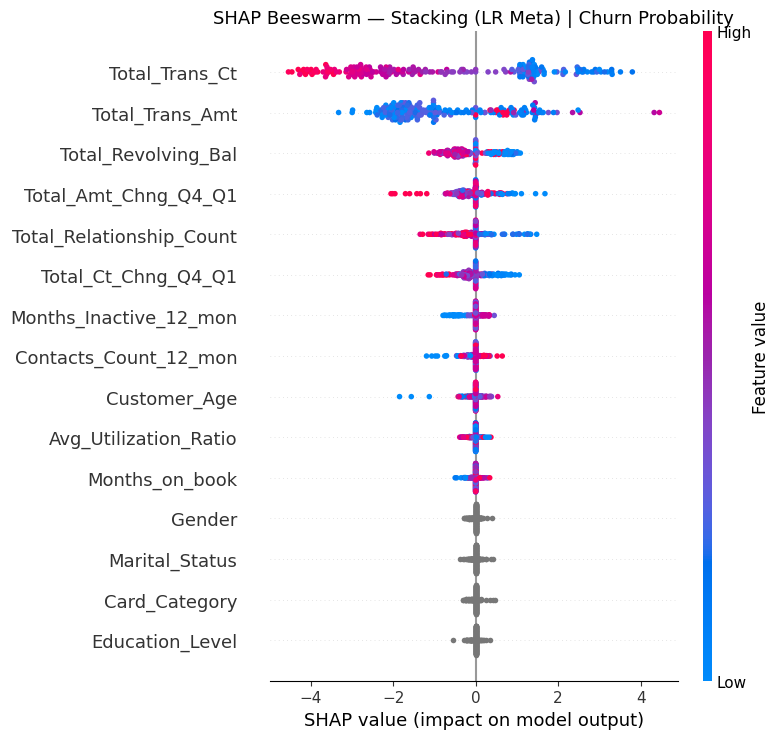

💾 Saved → shap_beeswarm.png


In [51]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_explain,
    plot_type='dot',          # beeswarm — shows distribution & direction
    max_display=15,           # top-15 features
    show=False
)
plt.title('SHAP Beeswarm — Stacking (LR Meta) | Churn Probability', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → shap_beeswarm.png')

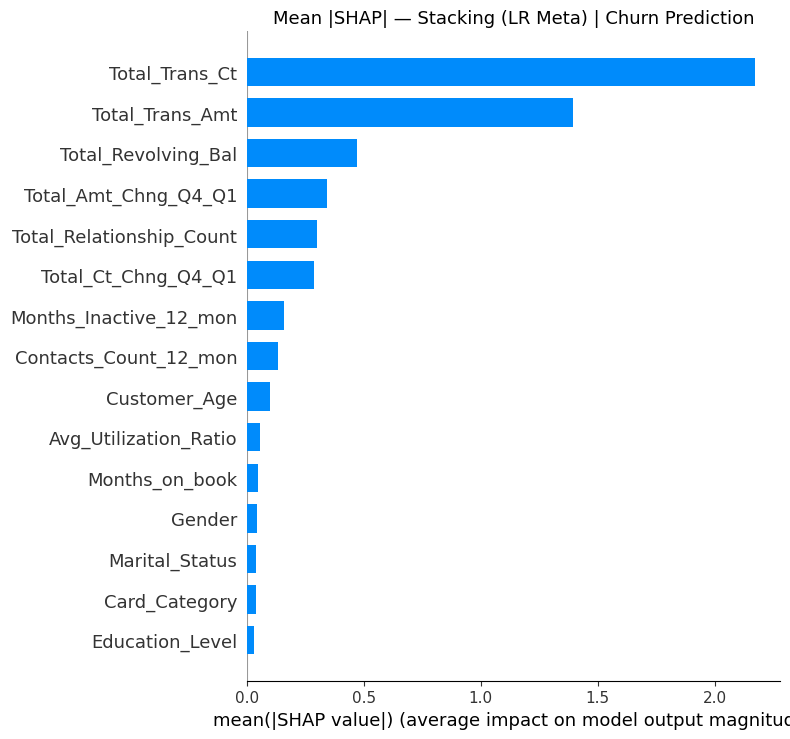

💾 Saved → shap_bar.png


In [52]:
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Mean |SHAP| — Stacking (LR Meta) | Churn Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → shap_bar.png')

In [53]:
probs = best_model.predict_proba(X_explain)[:, 1]
highest_risk_idx = int(np.argmax(probs))

print(f'Explaining customer at index {highest_risk_idx} ')
print(f'  → Predicted churn probability : {probs[highest_risk_idx]:.3f}')
print(f'  → Top features for this person:')
row_shap = shap_values[highest_risk_idx]
top_feat = pd.Series(np.abs(row_shap), index=X_explain.columns).nlargest(8)
print(top_feat.to_string())

# Interactive force plot (renders in Jupyter)
shap.initjs()
force_plot = shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[highest_risk_idx],
    features=X_explain.iloc[highest_risk_idx],
    feature_names=list(X_explain.columns),
    link='logit',
    matplotlib=False  # set True for static PNG instead
)
force_plot

Explaining customer at index 70 
  → Predicted churn probability : 0.999
  → Top features for this person:
Total_Trans_Ct              3.509148
Total_Trans_Amt             1.885679
Total_Relationship_Count    0.989058
Total_Revolving_Bal         0.968397
Gender                      0.392641
Customer_Age                0.268944
Total_Ct_Chng_Q4_Q1         0.218552
Months_on_book              0.179882


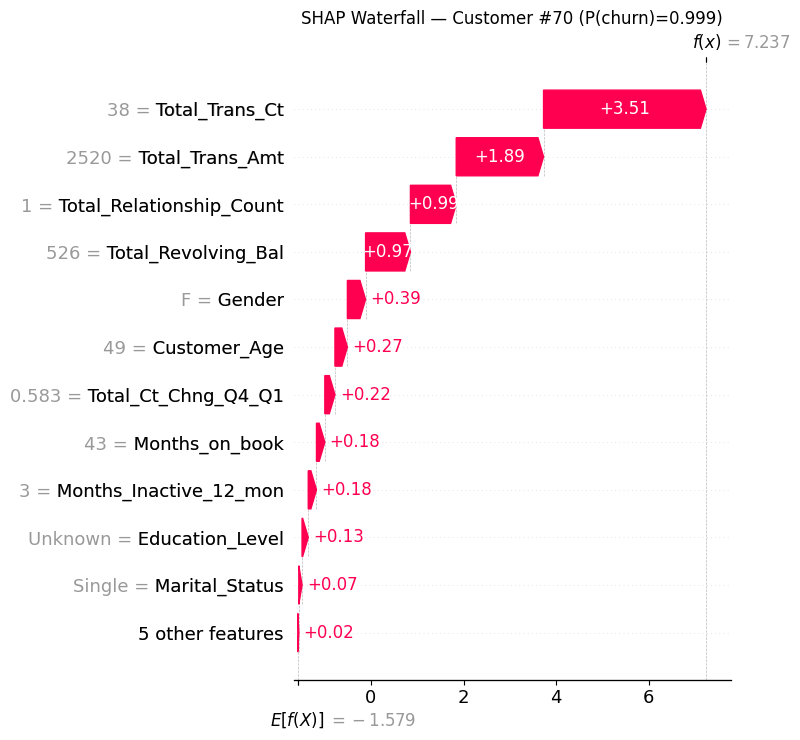

💾 Saved → shap_waterfall.png


In [54]:
# Build a shap.Explanation object for the waterfall plot
explanation = shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=explainer.expected_value,
    data=X_explain.iloc[highest_risk_idx].values,
    feature_names=list(X_explain.columns)
)

shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{highest_risk_idx} (P(churn)={probs[highest_risk_idx]:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → shap_waterfall.png')

In [59]:
import cloudpickle, json, os
from datetime import datetime

# ── Output directory ──────────────────────────────────────────────────────────
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Save each model ───────────────────────────────────────────────────────────
# joblib is preferred over pickle for sklearn/xgboost pipelines:
#   • faster serialisation of large numpy arrays
#   • better cross-platform compatibility
#   • compress=3 reduces file size ~60-70% with minimal speed cost

MODELS_TO_SAVE = {
    'stacking_lr_meta': models['Stacking (LR Meta)'],
    'stacking_xgb_meta': models['Stacking (XGB Meta)'],
    'xgboost': models['XGBoost']
}
NUM_FEATURES = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]
CAT_FEATURES = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

saved_files = {}
for name, model in MODELS_TO_SAVE.items():
    path = os.path.join(MODEL_DIR, f'{name}.pkl')          # .pkl extension for cloudpickle
    with open(path, 'wb') as f:
        cloudpickle.dump(model, f)
    size_mb = os.path.getsize(path) / 1e6
    saved_files[name] = path
    print(f'  ✅ {name:25s} → {path}  ({size_mb:.1f} MB)')

# ── Write shared metadata ─────────────────────────────────────────────────────
# Streamlit reads this once at startup — no hard-coding needed in app.py
meta = {
    'trained_at':    datetime.now().isoformat(timespec='seconds'),
    'threshold':     THRESHOLD,
    'input_features': list(X_train.columns),          # raw features before engineering
    'num_features':  NUM_FEATURES,
    'cat_features':  CAT_FEATURES,

    'models': {
        'stacking_lr_meta':  'models/stacking_lr_meta.joblib',
        'stacking_xgb_meta': 'models/stacking_xgb_meta.joblib',
        'xgboost':           'models/xgboost.joblib',
    },
    'display_names': {
        'stacking_lr_meta':  'Stacking (LR Meta)',
        'stacking_xgb_meta': 'Stacking (XGB Meta)',
        'xgboost':           'XGBoost',
    }
}

meta_path = os.path.join(MODEL_DIR, 'model_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'\n  ✅ Metadata         → {meta_path}')
print(f'\n📁 models/ directory:')
for fn in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, fn)) / 1e6
    print(f'   {fn:35s}  {size:.1f} MB')

  ✅ stacking_lr_meta          → models/stacking_lr_meta.pkl  (6.8 MB)
  ✅ stacking_xgb_meta         → models/stacking_xgb_meta.pkl  (7.1 MB)
  ✅ xgboost                   → models/xgboost.pkl  (0.5 MB)

  ✅ Metadata         → models/model_meta.json

📁 models/ directory:
   xgboost.pkl                          0.5 MB
   stacking_lr_meta.joblib              0.0 MB
   stacking_xgb_meta.pkl                7.1 MB
   stacking_lr_meta.pkl                 6.8 MB
   model_meta.json                      0.0 MB
